In [1]:
#Import the necessary libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the image
image = cv2.imread('/Users/piyushagarwal/Documents/Python Files/CV/00-puppy.jpg')

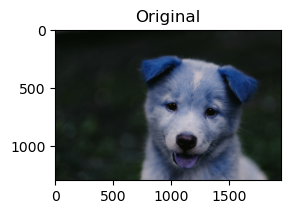

In [3]:
#Plot the original image
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image)

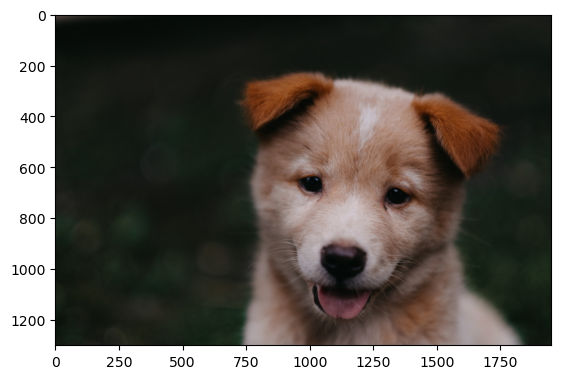

In [4]:
imgThen = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(imgThen)

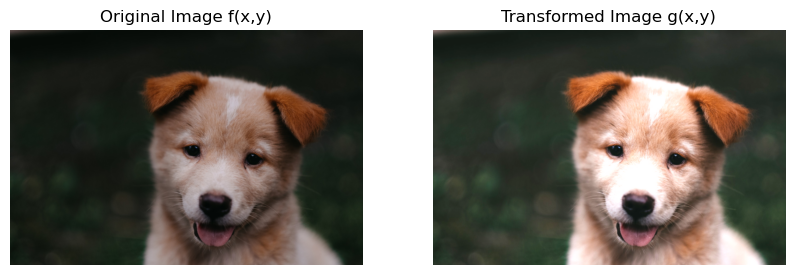

In [5]:
brightness = 10 
contrast = 1.5  
imageNow = cv2.addWeighted(imgThen, contrast, np.zeros(imgThen.shape, imgThen.dtype), 0, brightness)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imgThen)
plt.title("Original Image f(x,y)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imageNow)
plt.title("Transformed Image g(x,y)")
plt.axis('off')

plt.show()

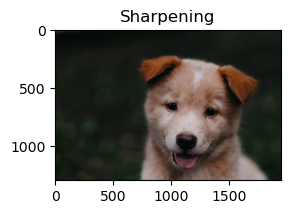

In [6]:
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

# Sharpen the image
sharpened_image = cv2.filter2D(imgThen, -1, kernel)

#Plot the sharpened image
plt.subplot(1, 2, 2)
plt.title("Sharpening")
plt.imshow(sharpened_image)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-139.0..146.0].


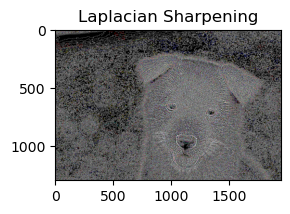

In [7]:
# Sharpen the image using the Laplacian operator
sharpened_image2 = cv2.Laplacian(imgThen, cv2.CV_64F)

#Plot the sharpened image
plt.subplot(1, 2, 2)
plt.title("Laplacian Sharpening")
plt.imshow(sharpened_image2)
plt.show()

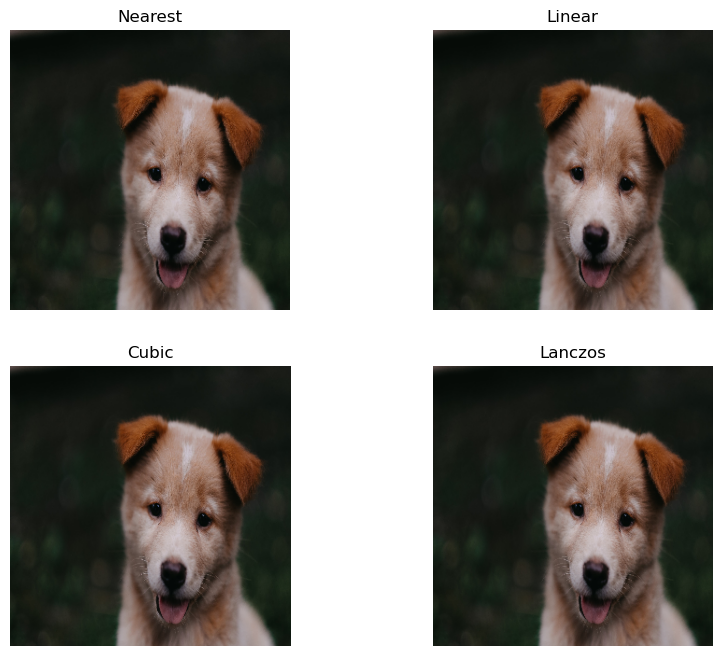

In [8]:
methods = [
    ("Nearest", cv2.INTER_NEAREST),
    ("Linear", cv2.INTER_LINEAR),
    ("Cubic", cv2.INTER_CUBIC),
    ("Lanczos", cv2.INTER_LANCZOS4)
]

plt.figure(figsize=(10,8))

for i, (name, method) in enumerate(methods):
    resized = cv2.resize(imgThen, (300,300), interpolation=method)
    plt.subplot(2,2,i+1)
    plt.imshow(resized)
    plt.title(name)
    plt.axis("off")

plt.show()

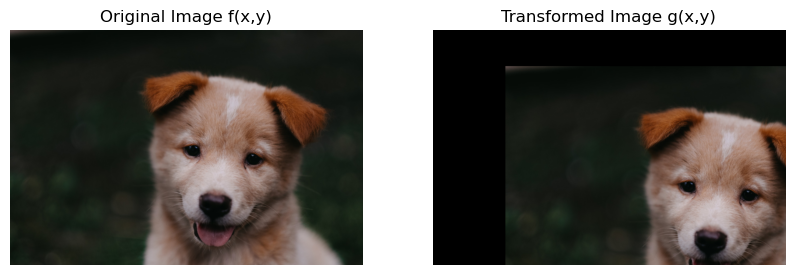

In [9]:
tx, ty = 400, 200
T = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])
imageNow = cv2.warpAffine(imgThen, T, (imgThen.shape[1], imgThen.shape[0]))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imgThen)
plt.title("Original Image f(x,y)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imageNow)
plt.title("Transformed Image g(x,y)")
plt.axis('off')

plt.show()

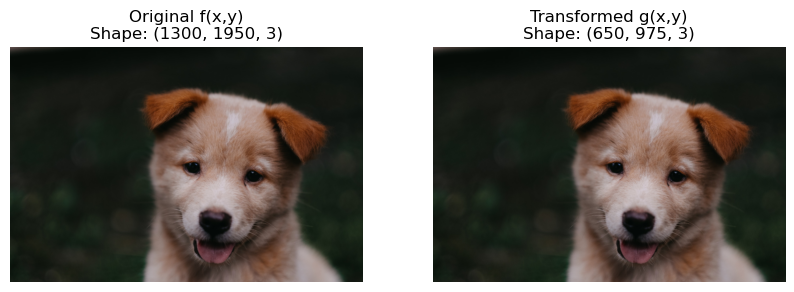

In [10]:
imgNow = cv2.resize(imgThen, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imgThen)
plt.title(f"Original f(x,y)\nShape: {imgThen.shape}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imgNow)
plt.title(f"Transformed g(x,y)\nShape: {imgNow.shape}")
plt.axis('off')

plt.show()

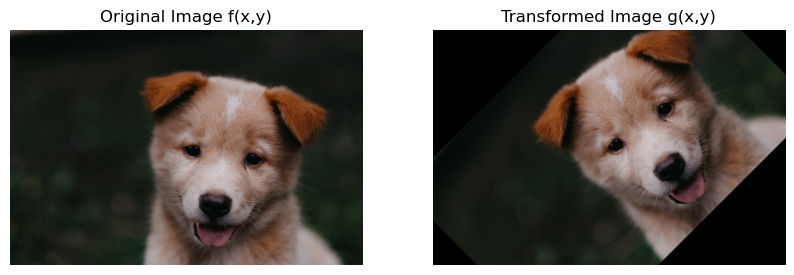

In [11]:
h, w = imgThen.shape[:2]
center = (w//2, h//2)
angle = 45
scale = 1.0
R = cv2.getRotationMatrix2D(center, angle, scale)
imgNow = cv2.warpAffine(imgThen, R, (w, h))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imgThen)
plt.title("Original Image f(x,y)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imgNow)
plt.title("Transformed Image g(x,y)")
plt.axis('off')

plt.show()

In [12]:
imgThen.shape

(1300, 1950, 3)